# Eleições Gerais 2022 — Segmentação do Perfil de Candidaturas com Machine Learning

## Planejamento da Análise

### 1. Contexto do Projeto

As Eleições Gerais de 2022 geraram um amplo conjunto de dados públicos sobre candidaturas, patrimônio declarado, receitas e despesas de campanha e resultados eleitorais.

Este projeto utiliza dados oficiais do Tribunal Superior Eleitoral (TSE) para analisar candidaturas ao cargo de Deputado Federal no estado de São Paulo.

O objetivo é aplicar técnicas de Análise de Dados e Machine Learning para identificar grupos de candidaturas com características semelhantes.

### 2. Objetivo

Utilizar clusterização com K-Means para segmentar as candidaturas de acordo com características numéricas presentes nos dados eleitorais.

A análise busca compreender quais perfis surgem naturalmente a partir dos dados, sem definir previamente os grupos.

### 3. Dados utilizados

Serão utilizados dados públicos das Eleições Gerais de 2022 disponibilizados pelo Tribunal Superior Eleitoral (TSE), contendo informações sobre:

- perfil das candidaturas;
- patrimônio declarado;
- receitas de campanha;
- despesas de campanha;
- quantidade de votos.

### 4. Pergunta principal

“Quais perfis de candidaturas a Deputado Federal em São Paulo podem ser identificados a partir de características financeiras e patrimoniais nas Eleições de 2022?”

### 5. Técnica de Machine Learning

Será utilizado o algoritmo **K-Means**, uma técnica de aprendizado não supervisionado utilizada para agrupar observações com características semelhantes.

Os grupos serão definidos pelo algoritmo e posteriormente analisados e interpretados com base nas características das candidaturas.

# 1.0 Imports 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
 
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 2.0 Preparação dos dados - seleção das colunas

In [2]:
# Carregar a base de candidaturas
df_candidatos = pd.read_csv('C:/Users/Felipe/Desktop/Clusterização/Dados/consulta_cand_2022_SP.csv',  sep=';', encoding='latin1')

In [3]:
df_candidatos.shape

(3659, 50)

In [4]:
# Descobrir quais colunas existem
df_candidatos.columns.tolist()

['DT_GERACAO',
 'HH_GERACAO',
 'ANO_ELEICAO',
 'CD_TIPO_ELEICAO',
 'NM_TIPO_ELEICAO',
 'NR_TURNO',
 'CD_ELEICAO',
 'DS_ELEICAO',
 'DT_ELEICAO',
 'TP_ABRANGENCIA',
 'SG_UF',
 'SG_UE',
 'NM_UE',
 'CD_CARGO',
 'DS_CARGO',
 'SQ_CANDIDATO',
 'NR_CANDIDATO',
 'NM_CANDIDATO',
 'NM_URNA_CANDIDATO',
 'NM_SOCIAL_CANDIDATO',
 'NR_CPF_CANDIDATO',
 'DS_EMAIL',
 'CD_SITUACAO_CANDIDATURA',
 'DS_SITUACAO_CANDIDATURA',
 'TP_AGREMIACAO',
 'NR_PARTIDO',
 'SG_PARTIDO',
 'NM_PARTIDO',
 'NR_FEDERACAO',
 'NM_FEDERACAO',
 'SG_FEDERACAO',
 'DS_COMPOSICAO_FEDERACAO',
 'SQ_COLIGACAO',
 'NM_COLIGACAO',
 'DS_COMPOSICAO_COLIGACAO',
 'SG_UF_NASCIMENTO',
 'DT_NASCIMENTO',
 'NR_TITULO_ELEITORAL_CANDIDATO',
 'CD_GENERO',
 'DS_GENERO',
 'CD_GRAU_INSTRUCAO',
 'DS_GRAU_INSTRUCAO',
 'CD_ESTADO_CIVIL',
 'DS_ESTADO_CIVIL',
 'CD_COR_RACA',
 'DS_COR_RACA',
 'CD_OCUPACAO',
 'DS_OCUPACAO',
 'CD_SIT_TOT_TURNO',
 'DS_SIT_TOT_TURNO']

In [5]:
# Verificar os cargos
df_candidatos['DS_CARGO'].value_counts()

DEPUTADO ESTADUAL    2059
DEPUTADO FEDERAL     1540
VICE-GOVERNADOR        14
GOVERNADOR             12
2º SUPLENTE            12
SENADOR                11
1º SUPLENTE            11
Name: DS_CARGO, dtype: int64

In [6]:
# Filtrar apenas candidaturas a Deputado Federal

df_deputados = df_candidatos[df_candidatos['DS_CARGO'] == 'DEPUTADO FEDERAL'].copy()
df_deputados.shape

(1540, 50)

In [7]:
# Selecionar apenas as informações necessárias para a análise

colunas_candidatos = [
    'SQ_CANDIDATO',
    'NR_CANDIDATO',
    'NM_CANDIDATO',
    'NM_URNA_CANDIDATO',
    'SG_PARTIDO',
    'DS_SITUACAO_CANDIDATURA',
    'DT_NASCIMENTO',
    'DS_GENERO',
    'DS_GRAU_INSTRUCAO',
    'DS_OCUPACAO',
    'DS_SIT_TOT_TURNO'
]

In [8]:
df_deputados = df_deputados[colunas_candidatos].copy()
df_deputados.shape

(1540, 11)

In [9]:
df_deputados['SQ_CANDIDATO'].nunique()

1540

In [10]:
# Carregar a base de bens declarados

df_bens = pd.read_csv('C:/Users/Felipe/Desktop/Clusterização/Dados/bem_candidato_2022_SP.csv', sep=';', encoding='latin1')

df_bens.shape

(13931, 19)

In [11]:
df_bens.columns.tolist()

['DT_GERACAO',
 'HH_GERACAO',
 'ANO_ELEICAO',
 'CD_TIPO_ELEICAO',
 'NM_TIPO_ELEICAO',
 'CD_ELEICAO',
 'DS_ELEICAO',
 'DT_ELEICAO',
 'SG_UF',
 'SG_UE',
 'NM_UE',
 'SQ_CANDIDATO',
 'NR_ORDEM_BEM_CANDIDATO',
 'CD_TIPO_BEM_CANDIDATO',
 'DS_TIPO_BEM_CANDIDATO',
 'DS_BEM_CANDIDATO',
 'VR_BEM_CANDIDATO',
 'DT_ULT_ATUAL_BEM_CANDIDATO',
 'HH_ULT_ATUAL_BEM_CANDIDATO']

In [12]:
# Selecionar apenas as colunas necessárias

df_bens = df_bens[['SQ_CANDIDATO', 'DS_TIPO_BEM_CANDIDATO', 'VR_BEM_CANDIDATO']].copy()

df_bens.shape

(13931, 3)

In [13]:
# Carregar a base de receitas de campanha

df_receitas = pd.read_csv('C:/Users/Felipe/Desktop/Clusterização/Dados/receitas_candidatos_2022_SP.csv', sep=';', encoding='latin1')

df_receitas.shape

(40138, 60)

In [14]:
df_receitas.columns.tolist()


['DT_GERACAO',
 'HH_GERACAO',
 'AA_ELEICAO',
 'CD_TIPO_ELEICAO',
 'NM_TIPO_ELEICAO',
 'CD_ELEICAO',
 'DS_ELEICAO',
 'DT_ELEICAO',
 'ST_TURNO',
 'TP_PRESTACAO_CONTAS',
 'DT_PRESTACAO_CONTAS',
 'SQ_PRESTADOR_CONTAS',
 'SG_UF',
 'SG_UE',
 'NM_UE',
 'NR_CNPJ_PRESTADOR_CONTA',
 'CD_CARGO',
 'DS_CARGO',
 'SQ_CANDIDATO',
 'NR_CANDIDATO',
 'NM_CANDIDATO',
 'NR_CPF_CANDIDATO',
 'NR_CPF_VICE_CANDIDATO',
 'NR_PARTIDO',
 'SG_PARTIDO',
 'NM_PARTIDO',
 'CD_FONTE_RECEITA',
 'DS_FONTE_RECEITA',
 'CD_ORIGEM_RECEITA',
 'DS_ORIGEM_RECEITA',
 'CD_NATUREZA_RECEITA',
 'DS_NATUREZA_RECEITA',
 'CD_ESPECIE_RECEITA',
 'DS_ESPECIE_RECEITA',
 'CD_CNAE_DOADOR',
 'DS_CNAE_DOADOR',
 'NR_CPF_CNPJ_DOADOR',
 'NM_DOADOR',
 'NM_DOADOR_RFB',
 'CD_ESFERA_PARTIDARIA_DOADOR',
 'DS_ESFERA_PARTIDARIA_DOADOR',
 'SG_UF_DOADOR',
 'CD_MUNICIPIO_DOADOR',
 'NM_MUNICIPIO_DOADOR',
 'SQ_CANDIDATO_DOADOR',
 'NR_CANDIDATO_DOADOR',
 'CD_CARGO_CANDIDATO_DOADOR',
 'DS_CARGO_CANDIDATO_DOADOR',
 'NR_PARTIDO_DOADOR',
 'SG_PARTIDO_DOADOR',
 'NM

In [15]:
# Selecionar apenas as colunas necessárias

df_receitas = df_receitas[['SQ_CANDIDATO', 'DS_ORIGEM_RECEITA', 'VR_RECEITA']].copy()

df_receitas.shape

(40138, 3)

In [16]:
# Carregar a base de despesas contratadas de campanha

df_despesas = pd.read_csv('C:/Users/Felipe/Desktop/Clusterização/Dados/despesas_contratadas_candidatos_2022_SP.csv', sep=';', encoding='latin1')
df_despesas.shape


(317391, 53)

In [17]:
df_despesas.columns.tolist()


['DT_GERACAO',
 'HH_GERACAO',
 'AA_ELEICAO',
 'CD_TIPO_ELEICAO',
 'NM_TIPO_ELEICAO',
 'CD_ELEICAO',
 'DS_ELEICAO',
 'DT_ELEICAO',
 'ST_TURNO',
 'TP_PRESTACAO_CONTAS',
 'DT_PRESTACAO_CONTAS',
 'SQ_PRESTADOR_CONTAS',
 'SG_UF',
 'SG_UE',
 'NM_UE',
 'NR_CNPJ_PRESTADOR_CONTA',
 'CD_CARGO',
 'DS_CARGO',
 'SQ_CANDIDATO',
 'NR_CANDIDATO',
 'NM_CANDIDATO',
 'NR_CPF_CANDIDATO',
 'NR_CPF_VICE_CANDIDATO',
 'NR_PARTIDO',
 'SG_PARTIDO',
 'NM_PARTIDO',
 'CD_TIPO_FORNECEDOR',
 'DS_TIPO_FORNECEDOR',
 'CD_CNAE_FORNECEDOR',
 'DS_CNAE_FORNECEDOR',
 'NR_CPF_CNPJ_FORNECEDOR',
 'NM_FORNECEDOR',
 'NM_FORNECEDOR_RFB',
 'CD_ESFERA_PART_FORNECEDOR',
 'DS_ESFERA_PART_FORNECEDOR',
 'SG_UF_FORNECEDOR',
 'CD_MUNICIPIO_FORNECEDOR',
 'NM_MUNICIPIO_FORNECEDOR',
 'SQ_CANDIDATO_FORNECEDOR',
 'NR_CANDIDATO_FORNECEDOR',
 'CD_CARGO_FORNECEDOR',
 'DS_CARGO_FORNECEDOR',
 'NR_PARTIDO_FORNECEDOR',
 'SG_PARTIDO_FORNECEDOR',
 'NM_PARTIDO_FORNECEDOR',
 'DS_TIPO_DOCUMENTO',
 'NR_DOCUMENTO',
 'CD_ORIGEM_DESPESA',
 'DS_ORIGEM_DESPESA

In [18]:
# Selecionar apenas as colunas necessárias

df_despesas = df_despesas[['SQ_CANDIDATO', 'DS_ORIGEM_DESPESA', 'VR_DESPESA_CONTRATADA']].copy()

df_despesas.shape

(317391, 3)

In [19]:
# Carregar apenas as colunas necessárias da base de votação

caminho_votos = 'C:/Users/Felipe/Desktop/Clusterização/Dados/votacao_candidato_munzona_2022_SP.csv'

colunas_votos = pd.read_csv(
    caminho_votos,
    sep=';',
    encoding='latin1',
    nrows=0
).columns.tolist()

colunas_votos 

['DT_GERACAO',
 'HH_GERACAO',
 'ANO_ELEICAO',
 'CD_TIPO_ELEICAO',
 'NM_TIPO_ELEICAO',
 'NR_TURNO',
 'CD_ELEICAO',
 'DS_ELEICAO',
 'DT_ELEICAO',
 'TP_ABRANGENCIA',
 'SG_UF',
 'SG_UE',
 'NM_UE',
 'CD_MUNICIPIO',
 'NM_MUNICIPIO',
 'NR_ZONA',
 'CD_CARGO',
 'DS_CARGO',
 'SQ_CANDIDATO',
 'NR_CANDIDATO',
 'NM_CANDIDATO',
 'NM_URNA_CANDIDATO',
 'NM_SOCIAL_CANDIDATO',
 'CD_SITUACAO_CANDIDATURA',
 'DS_SITUACAO_CANDIDATURA',
 'CD_DETALHE_SITUACAO_CAND',
 'DS_DETALHE_SITUACAO_CAND',
 'CD_SITUACAO_JULGAMENTO',
 'DS_SITUACAO_JULGAMENTO',
 'CD_SITUACAO_CASSACAO',
 'DS_SITUACAO_CASSACAO',
 'CD_SITUACAO_DCONST_DIPLOMA',
 'DS_SITUACAO_DCONST_DIPLOMA',
 'TP_AGREMIACAO',
 'NR_PARTIDO',
 'SG_PARTIDO',
 'NM_PARTIDO',
 'NR_FEDERACAO',
 'NM_FEDERACAO',
 'SG_FEDERACAO',
 'DS_COMPOSICAO_FEDERACAO',
 'SQ_COLIGACAO',
 'NM_COLIGACAO',
 'DS_COMPOSICAO_COLIGACAO',
 'ST_VOTO_EM_TRANSITO',
 'QT_VOTOS_NOMINAIS',
 'NM_TIPO_DESTINACAO_VOTOS',
 'QT_VOTOS_NOMINAIS_VALIDOS',
 'CD_SIT_TOT_TURNO',
 'DS_SIT_TOT_TURNO']

In [20]:
df_votos = pd.read_csv(
    caminho_votos,
    sep=';',
    encoding='latin1',
    usecols=['SQ_CANDIDATO', 'DS_CARGO', 'QT_VOTOS_NOMINAIS']
)

In [21]:
# Filtrar apenas as candidaturas a Deputado Federal

df_votos_deputados = df_votos[
    df_votos['DS_CARGO'] == 'Deputado Federal'
].copy()

In [22]:
df_votos_deputados.shape

(1114620, 3)

# 3.0 Limpeza e Tratamento dos Dados.

## 3.1 TRATAMENTO DA BASE DE CANDIDATOS

In [23]:
# Verificar a quantidade de valores ausentes em cada coluna
df_deputados.isnull().sum()

SQ_CANDIDATO               0
NR_CANDIDATO               0
NM_CANDIDATO               0
NM_URNA_CANDIDATO          0
SG_PARTIDO                 0
DS_SITUACAO_CANDIDATURA    0
DT_NASCIMENTO              1
DS_GENERO                  0
DS_GRAU_INSTRUCAO          0
DS_OCUPACAO                0
DS_SIT_TOT_TURNO           0
dtype: int64

In [24]:
# Identificar o candidato que não possui data de nascimento

df_deputados[df_deputados['DT_NASCIMENTO'].isnull()]

,SQ_CANDIDATO,NR_CANDIDATO,NM_CANDIDATO,NM_URNA_CANDIDATO,SG_PARTIDO,DS_SITUACAO_CANDIDATURA,DT_NASCIMENTO,DS_GENERO,DS_GRAU_INSTRUCAO,DS_OCUPACAO,DS_SIT_TOT_TURNO
951,250001597695,3001,MARINA HELENA CUNHA PEREIRA SANTOS,MARINA HELENA,NOVO,APTO,NaN,NÃO DIVULGÁVEL,NÃO DIVULGÁVEL,NÃO DIVULGÁVEL,SUPLENTE


In [25]:
# Visualizar o formato original das datas de nascimento

df_deputados['DT_NASCIMENTO'].head()

1    09/07/1962
2    12/10/1969
3    22/02/1979
4    12/04/1978
6    01/02/1972
Name: DT_NASCIMENTO, dtype: object

In [26]:
# Converter a coluna de nascimento de texto para o formato de data
df_deputados['DT_NASCIMENTO'] = pd.to_datetime(
    df_deputados['DT_NASCIMENTO'],
    format='%d/%m/%Y',
    errors='coerce'
)

In [27]:
# Calcular a idade na data da eleição
# O código subtrai 1 quando o candidato ainda não havia feito
# aniversário até 02/10/2022

data_eleicao = pd.Timestamp('2022-10-02')

df_deputados['IDADE'] = (
    data_eleicao.year
    - df_deputados['DT_NASCIMENTO'].dt.year
    - (
        (data_eleicao.month < df_deputados['DT_NASCIMENTO'].dt.month)
        |
        (
            (data_eleicao.month == df_deputados['DT_NASCIMENTO'].dt.month)
            & (data_eleicao.day < df_deputados['DT_NASCIMENTO'].dt.day)
        )
    )
)

In [28]:
# Conferir se a idade foi calculada corretamente

df_deputados[['DT_NASCIMENTO', 'IDADE']].head()

,DT_NASCIMENTO,IDADE
1,1962-07-09,60.0
2,1969-10-12,52.0
3,1979-02-22,43.0
4,1978-04-12,44.0
6,1972-02-01,50.0


In [29]:
# Analisar as estatísticas da idade para identificar possíveis valores incorretos

df_deputados['IDADE'].describe()

count    1539.000000
mean       49.493827
std        11.140453
min        21.000000
25%        42.000000
50%        50.000000
75%        57.000000
max        92.000000
Name: IDADE, dtype: float64

## 3.2 TRATAMENTO DO PATRIMÔNIO

In [30]:
# Converter o valor dos bens de texto para número
# A base utiliza vírgula como separador decimal
df_bens['VR_BEM_CANDIDATO'] = (
    df_bens['VR_BEM_CANDIDATO']
    .str.replace(',', '.', regex=False)
    .astype(float)
)

In [31]:
# Agrupar os bens por candidato e somar seus valores
# Cada candidato passa a ter um único valor de patrimônio totaldf_patrimonio = (
df_patrimonio = (
    df_bens
    .groupby('SQ_CANDIDATO', as_index=False)['VR_BEM_CANDIDATO']
    .sum()
    .rename(columns={'VR_BEM_CANDIDATO': 'PATRIMONIO_TOTAL'})
)

df_patrimonio.head()


,SQ_CANDIDATO,PATRIMONIO_TOTAL
0,250001597662,110521.56
1,250001597663,4372852.61
2,250001597664,185000.00
3,250001597665,1773000.00
4,250001597666,100000.00


In [32]:
# Adicionar o patrimônio total à base principal de Deputados Federais
# O SQ_CANDIDATO é utilizado como chave para relacionar as duas tabelas

df_deputados = df_deputados.merge(df_patrimonio, on='SQ_CANDIDATO', how='left')

In [33]:
# Candidatos sem registro na base de bens ficam com patrimônio igual a zero
df_deputados['PATRIMONIO_TOTAL'] = (
    df_deputados['PATRIMONIO_TOTAL'].fillna(0)
)

# Confirmar que não restaram valores ausentes no patrimônio
df_deputados['PATRIMONIO_TOTAL'].isnull().sum()

0

## 3.3 TRATAMENTO DAS RECEITAS DE CAMPANHA


In [34]:
# Verificar o tipo de dado da coluna de receita
df_receitas['VR_RECEITA'].dtype

dtype('O')

In [35]:
# Visualizar alguns valores para entender como estão armazenados
df_receitas['VR_RECEITA'].head(10) 
 

0      1013,08
1    100000,00
2     13500,00
3      2500,00
4      3800,00
5     10000,00
6     10000,00
7     10000,00
8       850,00
9     50000,00
Name: VR_RECEITA, dtype: object

In [36]:
# Agrupar todas as receitas por candidato e calcular a receita total
# Cada candidato passa a ter apenas uma linha com o total recebido
df_receita_total = (
    df_receitas
    .groupby('SQ_CANDIDATO', as_index=False)['VR_RECEITA']
    .sum()
    .rename(columns={'VR_RECEITA': 'RECEITA_TOTAL'})
)

# Conferir os primeiros resultados da receita total por candidato
df_receita_total.head()

,SQ_CANDIDATO,RECEITA_TOTAL
0,250001597662,"564,33677,201000,00400,0010,0030,00150,0020,00"
1,250001597663,"564,33677,204000,00512,501210,00410,005000,002..."
2,250001597664,"500,00564,33677,201000,002500,00400,00"
3,250001597665,"564,33677,203000,00200,001000,00300,001000,002..."
4,250001597666,"564,33677,202000,001000,00150,000,011000,00100..."


In [37]:
# Adicionar a receita total à base principal de Deputados Federais
# SQ_CANDIDATO é a chave que relaciona as duas tabelas
df_deputados = df_deputados.merge(
    df_receita_total,
    on='SQ_CANDIDATO',
    how='left'
)

# Conferir o tamanho da base após o merge
df_deputados.shape

(1540, 14)

In [38]:
# Verificar quantos candidatos ficaram sem registro de receita
df_deputados['RECEITA_TOTAL'].isnull().sum() 

18

In [39]:
# Candidatos sem registro na base de receitas ficam com receita igual a zero
df_deputados['RECEITA_TOTAL'] = (
    df_deputados['RECEITA_TOTAL'].fillna(0)
)

# Confirmar que não restaram valores ausentes na receita total
df_deputados['RECEITA_TOTAL'].isnull().sum()

0

## 3.4 TRATAMENTO DAS DESPESAS DE CAMPANHA

In [40]:
# Remover a coluna DESPESA_TOTAL criada anteriormente de forma incorreta
# Ela será calculada novamente após a conversão correta dos valores
df_deputados = df_deputados.drop(
    columns=['DESPESA_TOTAL'],
    errors='ignore'
)

# Confirmar que DESPESA_TOTAL foi removida
'DESPESA_TOTAL' in df_deputados.columns

False

In [41]:
 # Verificar o tipo de dado da coluna de despesas
df_despesas['VR_DESPESA_CONTRATADA'].dtype

dtype('O')

In [42]:
# Visualizar alguns valores antes da conversão
df_despesas['VR_DESPESA_CONTRATADA'].head(10)

0        0,00
1     4956,00
2       22,00
3       22,00
4       16,00
5     9580,00
6     5000,00
7    10400,00
8     1500,00
9     3500,00
Name: VR_DESPESA_CONTRATADA, dtype: object

In [43]:
# Converter os valores de despesas de texto para número
# A base utiliza vírgula como separador decimal
df_despesas['VR_DESPESA_CONTRATADA'] = (
    df_despesas['VR_DESPESA_CONTRATADA']
    .str.replace(',', '.', regex=False)
    .astype(float)
)

In [44]:
# Confirmar que a coluna foi convertida para número
df_despesas['VR_DESPESA_CONTRATADA'].dtype

dtype('float64')

In [45]:
# Agrupar todas as despesas por candidato e calcular a despesa total
# Cada candidato passa a ter apenas uma linha com o total gasto na campanha
df_despesa_total = (
    df_despesas
    .groupby('SQ_CANDIDATO', as_index=False)['VR_DESPESA_CONTRATADA']
    .sum()
    .rename(columns={'VR_DESPESA_CONTRATADA': 'DESPESA_TOTAL'})
)

# Conferir os primeiros resultados
df_despesa_total.head()

,SQ_CANDIDATO,DESPESA_TOTAL
0,250001597662,1610.00
1,250001597663,11330.16
2,250001597664,6962.01
3,250001597665,16821.00
4,250001597666,9149.99


In [46]:
# Verificar quantos candidatos aparecem na tabela de despesas
df_despesa_total.shape

(3583, 2)

In [47]:
# Adicionar a despesa total à base principal de Deputados Federais
# SQ_CANDIDATO é a chave que relaciona as duas tabelas
df_deputados = df_deputados.merge(
    df_despesa_total,
    on='SQ_CANDIDATO',
    how='left'
)

# Conferir o tamanho da base após o merge
df_deputados.shape

(1540, 15)

In [48]:
# Verificar quantos candidatos ficaram sem registro de despesas
df_deputados['DESPESA_TOTAL'].isnull().sum()

18

In [49]:
# Candidatos sem registro na base de despesas ficam com despesa igual a zero
df_deputados['DESPESA_TOTAL'] = (
    df_deputados['DESPESA_TOTAL'].fillna(0)
)

# Confirmar que não restaram valores ausentes
df_deputados['DESPESA_TOTAL'].isnull().sum()

0

## 3.5  TRATAMENTO DOS VOTOS

In [50]:
# Visualizar os primeiros registros da base de votos
# O objetivo é conferir as colunas e como os dados estão organizados
df_votos_deputados.head()

,DS_CARGO,SQ_CANDIDATO,QT_VOTOS_NOMINAIS
0,Deputado Federal,250001620295,1
1,Deputado Federal,250001620257,0
2,Deputado Federal,250001620274,0
3,Deputado Federal,250001651398,0
4,Deputado Federal,250001651398,1


In [51]:
# Agrupar os votos por candidato e calcular o total de votos nominais
# Como cada candidato aparece em várias zonas/municípios,
# somamos todos os registros para obter sua votação total

df_votos_total = (
    df_votos_deputados
    .groupby('SQ_CANDIDATO', as_index=False)['QT_VOTOS_NOMINAIS']
    .sum()
    .rename(columns={'QT_VOTOS_NOMINAIS': 'VOTOS_TOTAL'})
)

# Conferir os primeiros resultados
df_votos_total.head()

,SQ_CANDIDATO,VOTOS_TOTAL
0,250001597662,536
1,250001597663,497
2,250001597664,622
3,250001597665,863
4,250001597666,641


In [52]:
# Verificar a quantidade de candidatos na tabela de votos agregados
df_votos_total.shape

(1429, 2)

In [53]:
# Identificar quantos candidatos da base principal
# não aparecem na tabela de votos

(~df_deputados['SQ_CANDIDATO'].isin(
    df_votos_total['SQ_CANDIDATO']
)).sum()


111

In [54]:
# Separar os candidatos que não aparecem na base de votos
candidatos_sem_votos = df_deputados[
    ~df_deputados['SQ_CANDIDATO'].isin(df_votos_total['SQ_CANDIDATO'])
]

# Verificar a situação das candidaturas que não aparecem na base de votos
candidatos_sem_votos['DS_SITUACAO_CANDIDATURA'].value_counts()


INAPTO    111
Name: DS_SITUACAO_CANDIDATURA, dtype: int64

In [55]:
# Adicionar o total de votos à base principal
# O left mantém todas as 1.540 candidaturas da nossa base

df_deputados = df_deputados.merge(
    df_votos_total,
    on='SQ_CANDIDATO',
    how='left'
)

# Conferir o tamanho da base após o merge
df_deputados.shape

(1540, 16)

## 3.6 Validação Final dos Dados Tratados



In [56]:
# Conferir o estado final da base após os tratamentos
df_deputados.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1540 entries, 0 to 1539
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   SQ_CANDIDATO             1540 non-null   int64         
 1   NR_CANDIDATO             1540 non-null   int64         
 2   NM_CANDIDATO             1540 non-null   object        
 3   NM_URNA_CANDIDATO        1540 non-null   object        
 4   SG_PARTIDO               1540 non-null   object        
 5   DS_SITUACAO_CANDIDATURA  1540 non-null   object        
 6   DT_NASCIMENTO            1539 non-null   datetime64[ns]
 7   DS_GENERO                1540 non-null   object        
 8   DS_GRAU_INSTRUCAO        1540 non-null   object        
 9   DS_OCUPACAO              1540 non-null   object        
 10  DS_SIT_TOT_TURNO         1540 non-null   object        
 11  IDADE                    1539 non-null   float64       
 12  PATRIMONIO_TOTAL         1540 non-

In [57]:
# Converter a receita total para formato numérico
df_deputados['RECEITA_TOTAL'] = pd.to_numeric(
    df_deputados['RECEITA_TOTAL'],
    errors='coerce'
)

# Conferir o tipo de dado e se a conversão criou valores ausentes
df_deputados['RECEITA_TOTAL'].dtype, df_deputados['RECEITA_TOTAL'].isnull().sum()

(dtype('float64'), 1522)

In [58]:
# Verificar o estado atual da coluna original de receitas
df_receitas['VR_RECEITA'].head(10)



0      1013,08
1    100000,00
2     13500,00
3      2500,00
4      3800,00
5     10000,00
6     10000,00
7     10000,00
8       850,00
9     50000,00
Name: VR_RECEITA, dtype: object

In [59]:
# Verificar o tipo atual dos valores da coluna original
df_receitas['VR_RECEITA'].dtype

dtype('O')

In [60]:
# Converter os valores de receita de texto para número
# A base utiliza vírgula como separador decimal

df_receitas['VR_RECEITA'] = (
    df_receitas['VR_RECEITA']
    .str.replace(',', '.', regex=False)
    .astype(float)
)

# Conferir se a conversão foi realizada corretamente
df_receitas['VR_RECEITA'].dtype

dtype('float64')

In [61]:
# Recalcular a receita total de cada candidato
# Agora a soma será realizada com valores numéricos

df_receita_total = (
    df_receitas
    .groupby('SQ_CANDIDATO', as_index=False)['VR_RECEITA']
    .sum()
    .rename(columns={'VR_RECEITA': 'RECEITA_TOTAL'})
)

# Conferir os primeiros resultados
df_receita_total.head()

,SQ_CANDIDATO,RECEITA_TOTAL
0,250001597662,2851.53
1,250001597663,12574.03
2,250001597664,5641.53
3,250001597665,18076.53
4,250001597666,10391.54


In [62]:
# Remover a coluna RECEITA_TOTAL que ficou incorreta durante a validação
df_deputados = df_deputados.drop(
    columns=['RECEITA_TOTAL']
)

# Adicionar novamente a receita total já corrigida
df_deputados = df_deputados.merge(
    df_receita_total,
    on='SQ_CANDIDATO',
    how='left'
)

# Conferir o tipo da variável e a quantidade de valores ausentes
df_deputados['RECEITA_TOTAL'].dtype, df_deputados['RECEITA_TOTAL'].isnull().sum()

(dtype('float64'), 18)

In [63]:
# Candidatos sem registro na base de receitas ficam com receita igual a zero
df_deputados['RECEITA_TOTAL'] = (
    df_deputados['RECEITA_TOTAL'].fillna(0)
)

# Confirmar que não restaram valores ausentes na receita total
df_deputados['RECEITA_TOTAL'].isnull().sum()

0

In [64]:
df_deputados.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1540 entries, 0 to 1539
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   SQ_CANDIDATO             1540 non-null   int64         
 1   NR_CANDIDATO             1540 non-null   int64         
 2   NM_CANDIDATO             1540 non-null   object        
 3   NM_URNA_CANDIDATO        1540 non-null   object        
 4   SG_PARTIDO               1540 non-null   object        
 5   DS_SITUACAO_CANDIDATURA  1540 non-null   object        
 6   DT_NASCIMENTO            1539 non-null   datetime64[ns]
 7   DS_GENERO                1540 non-null   object        
 8   DS_GRAU_INSTRUCAO        1540 non-null   object        
 9   DS_OCUPACAO              1540 non-null   object        
 10  DS_SIT_TOT_TURNO         1540 non-null   object        
 11  IDADE                    1539 non-null   float64       
 12  PATRIMONIO_TOTAL         1540 non-

# 4.0 Análise Exploratória dos Dados (EDA)

## 4.1 Estatísticas Descritivas


In [65]:
# Selecionar as principais variáveis numéricas para a análise
variaveis_numericas = [
    'IDADE',
    'PATRIMONIO_TOTAL',
    'RECEITA_TOTAL',
    'DESPESA_TOTAL'
]

# Visualizar as principais estatísticas descritivas
df_deputados[variaveis_numericas].describe()

,IDADE,PATRIMONIO_TOTAL,RECEITA_TOTAL,DESPESA_TOTAL
count,1539.000000,1.540000e+03,1.540000e+03,1.540000e+03
mean,49.493827,8.024797e+05,3.210111e+05,3.099081e+05
std,11.140453,3.273472e+06,6.529423e+05,6.444974e+05
min,21.000000,0.000000e+00,0.000000e+00,0.000000e+00
25%,42.000000,0.000000e+00,1.076756e+04,5.000000e+03
50%,50.000000,1.064969e+05,5.083565e+04,4.754422e+04
75%,57.000000,5.943590e+05,2.250000e+05,2.059551e+05
max,92.000000,8.844147e+07,3.790000e+06,3.453214e+06


## 4.2 Distribuição das Variáveis Numéricas


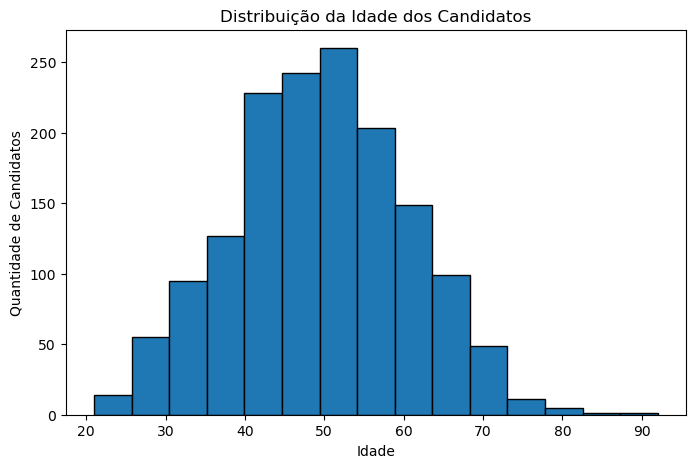

In [66]:
# Visualizar a distribuição da idade dos candidatos

plt.figure(figsize=(8, 5))

plt.hist(
    df_deputados['IDADE'].dropna(),
    bins=15,
    edgecolor='black'
)

plt.title('Distribuição da Idade dos Candidatos')
plt.xlabel('Idade')
plt.ylabel('Quantidade de Candidatos')

plt.show()

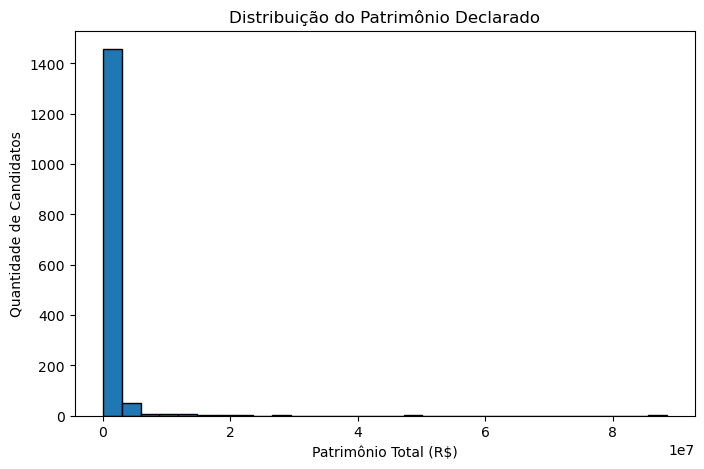

In [67]:
# Visualizar a distribuição do patrimônio declarado

plt.figure(figsize=(8, 5))

plt.hist(
    df_deputados['PATRIMONIO_TOTAL'],
    bins=30,
    edgecolor='black'
)

plt.title('Distribuição do Patrimônio Declarado')
plt.xlabel('Patrimônio Total (R$)')
plt.ylabel('Quantidade de Candidatos')

plt.show()

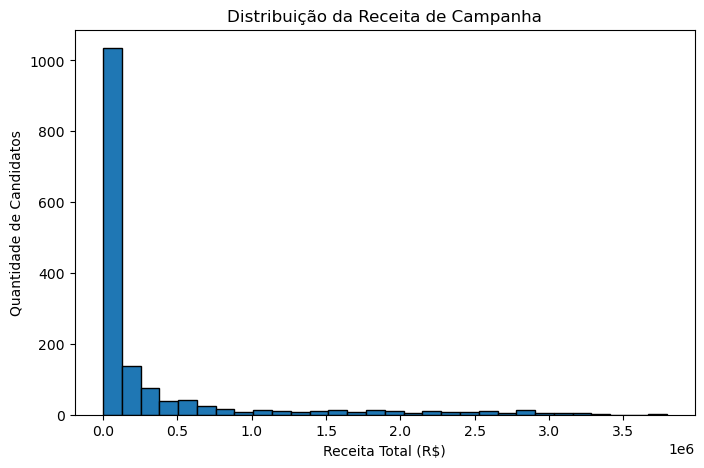

In [68]:
# Visualizar a distribuição da receita de campanha

plt.figure(figsize=(8, 5))

plt.hist(
    df_deputados['RECEITA_TOTAL'],
    bins=30,
    edgecolor='black'
)

plt.title('Distribuição da Receita de Campanha')
plt.xlabel('Receita Total (R$)')
plt.ylabel('Quantidade de Candidatos')

plt.show()


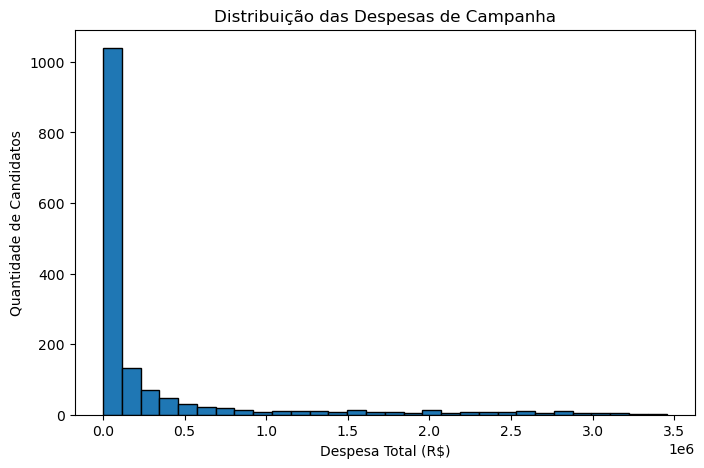

In [69]:
# Visualizar a distribuição das despesas de campanha

plt.figure(figsize=(8, 5))

plt.hist(
    df_deputados['DESPESA_TOTAL'],
    bins=30,
    edgecolor='black'
)

plt.title('Distribuição das Despesas de Campanha')
plt.xlabel('Despesa Total (R$)')
plt.ylabel('Quantidade de Candidatos')

plt.show()

## 4.3 Correlação entre as Variáveis


In [70]:
# Calcular a correlação entre as variáveis utilizadas na segmentação

correlacao = df_deputados[
    [
        'IDADE',
        'PATRIMONIO_TOTAL',
        'RECEITA_TOTAL',
        'DESPESA_TOTAL'
    ]
].corr()

# Visualizar a matriz de correlação
correlacao

,IDADE,PATRIMONIO_TOTAL,RECEITA_TOTAL,DESPESA_TOTAL
IDADE,1.000000,0.076715,0.050239,0.052587
PATRIMONIO_TOTAL,0.076715,1.000000,0.169150,0.161510
RECEITA_TOTAL,0.050239,0.169150,1.000000,0.994762
DESPESA_TOTAL,0.052587,0.161510,0.994762,1.000000


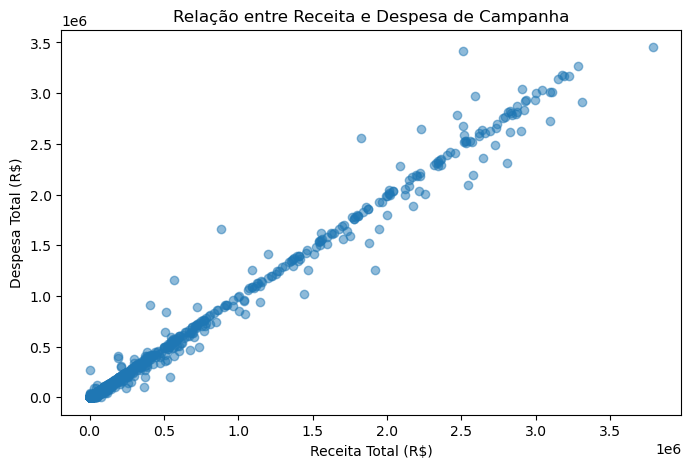

In [71]:
# Visualizar a relação entre receita e despesa de campanha

plt.figure(figsize=(8, 5))

plt.scatter(
    df_deputados['RECEITA_TOTAL'],
    df_deputados['DESPESA_TOTAL'],
    alpha=0.5
)

plt.title('Relação entre Receita e Despesa de Campanha')
plt.xlabel('Receita Total (R$)')
plt.ylabel('Despesa Total (R$)')

plt.show()

### Decisão sobre as variáveis

A análise apresentou uma correlação muito elevada entre receita e despesa de campanha (aproximadamente 0,995), também observada no gráfico de dispersão.

Como as duas variáveis apresentam comportamento muito semelhante, optou-se por utilizar apenas `RECEITA_TOTAL` na construção inicial dos clusters, evitando atribuir peso excessivo ao componente financeiro.

Dessa forma, as variáveis inicialmente selecionadas para o K-Means são:

- `IDADE`
- `PATRIMONIO_TOTAL`
- `RECEITA_TOTAL`

As variáveis de despesa, votos e resultado eleitoral serão mantidas para auxiliar posteriormente na interpretação dos grupos identificados.

## 4.4 Análise de Valores Extremos


In [72]:
# Visualizar os maiores valores de patrimônio declarado

df_deputados[
    ['NM_URNA_CANDIDATO', 'PATRIMONIO_TOTAL']
].sort_values(
    by='PATRIMONIO_TOTAL',
    ascending=False
).head(10)

,NM_URNA_CANDIDATO,PATRIMONIO_TOTAL
1187,PABLO MARÇAL,88441467.08
1167,ARTHUR P. MACHADO,49821285.26
389,ALEXIS FONTEYNE,26760146.21
714,ALBERTO MOURÃO,23287436.63
43,GILMAR GIMENES,20845776.62
369,WILSON PAIVA,20162312.99
1427,AUGUSTO DE ARRUDA BOTELHO,19135916.96
36,DR FREDERICK WASSEF,18311550.41
217,FLAVIUS,18000000.00
223,EDSON MOURA,15289241.00


In [73]:
# Visualizar os maiores valores de receita de campanha

df_deputados[
    ['NM_URNA_CANDIDATO', 'RECEITA_TOTAL']
].sort_values(
    by='RECEITA_TOTAL',
    ascending=False
).head(10)

,NM_URNA_CANDIDATO,RECEITA_TOTAL
342,ARNALDO JARDIM,3789999.99
1220,RENATA ABREU,3313917.40
359,PAULO TEIXEIRA,3281293.48
726,JOICE HASSELMANN,3221072.53
1283,PAULO ALEXANDRE BARBOSA,3188141.60
910,JOSÉ SERRA,3175000.00
1037,JONAS DONIZETTE,3147286.96
128,ALEX MANENTE,3107760.02
340,VANDERLEI MACRIS,3096833.36
791,MARCOS PEREIRA,3093528.55


#### Considerações sobre os valores extremos

A análise identificou valores elevados de patrimônio e receita em comparação com a maior parte das candidaturas. Esses registros não serão excluídos apenas por apresentarem valores extremos, pois podem representar características reais das candidaturas.

Antes da aplicação do K-Means, será avaliada uma transformação dos dados para reduzir a influência da forte assimetria observada nessas variáveis.

# Etapa 5 — Preparação dos Dados para o K-Means


## 5.1 Seleção das Variáveis do Modelo


In [74]:
# Criar uma base específica para o modelo de clusterização

df_modelo = df_deputados[
    [
        'SQ_CANDIDATO',
        'IDADE',
        'PATRIMONIO_TOTAL',
        'RECEITA_TOTAL'
    ]
].copy()

# Conferir a estrutura da nova base
df_modelo.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1540 entries, 0 to 1539
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   SQ_CANDIDATO      1540 non-null   int64  
 1   IDADE             1539 non-null   float64
 2   PATRIMONIO_TOTAL  1540 non-null   float64
 3   RECEITA_TOTAL     1540 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 60.2 KB


In [75]:
# Remover da base do modelo o registro sem informação de idade
df_modelo = df_modelo.dropna(
    subset=['IDADE']
).copy()

# Conferir o tamanho da base após o tratamento
df_modelo.shape


(1539, 4)

In [76]:
# Aplicar a transformação logarítmica nas variáveis financeiras
# As colunas originais serão mantidas para comparação

df_modelo['PATRIMONIO_LOG'] = np.log1p(
    df_modelo['PATRIMONIO_TOTAL']
)

df_modelo['RECEITA_LOG'] = np.log1p(
    df_modelo['RECEITA_TOTAL']
)

# Comparar os valores originais com os transformados
df_modelo[
    [
        'PATRIMONIO_TOTAL',
        'PATRIMONIO_LOG',
        'RECEITA_TOTAL',
        'RECEITA_LOG'
    ]
].head()

,PATRIMONIO_TOTAL,PATRIMONIO_LOG,RECEITA_TOTAL,RECEITA_LOG
0,0.0,0.0,0.0,0.000000
1,0.0,0.0,0.0,0.000000
2,0.0,0.0,0.0,0.000000
3,0.0,0.0,907650.0,13.718615
4,0.0,0.0,8950.0,9.099521


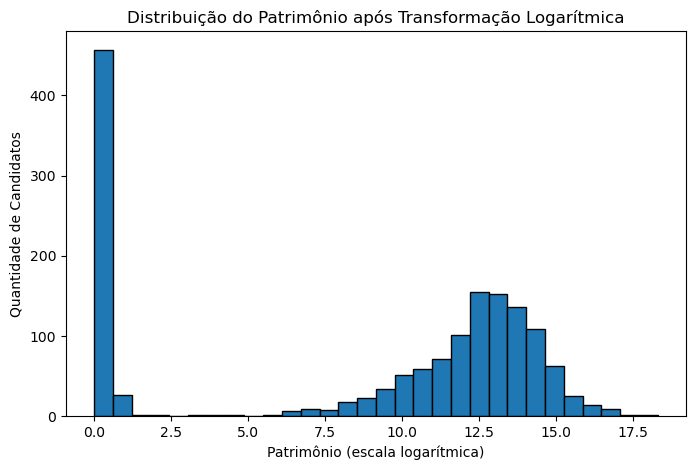

In [77]:
# Visualizar a distribuição do patrimônio após a transformação logarítmica

plt.figure(figsize=(8, 5))

plt.hist(
    df_modelo['PATRIMONIO_LOG'],
    bins=30,
    edgecolor='black'
)

plt.title('Distribuição do Patrimônio após Transformação Logarítmica')
plt.xlabel('Patrimônio (escala logarítmica)')
plt.ylabel('Quantidade de Candidatos')

plt.show()

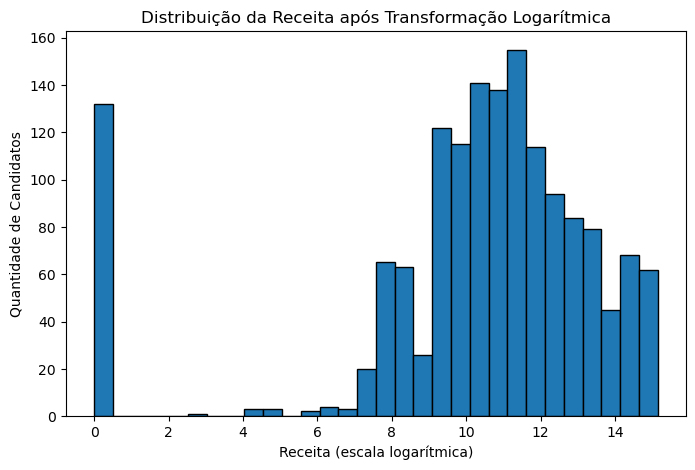

In [78]:
# Visualizar a distribuição da receita após a transformação logarítmica

plt.figure(figsize=(8, 5))

plt.hist(
    df_modelo['RECEITA_LOG'],
    bins=30,
    edgecolor='black'
)

plt.title('Distribuição da Receita após Transformação Logarítmica')
plt.xlabel('Receita (escala logarítmica)')
plt.ylabel('Quantidade de Candidatos')

plt.show()

## 5.1 Padronização das Variáveis


In [79]:
# Selecionar apenas as variáveis que serão utilizadas pelo K-Means

X = df_modelo[
    [
        'IDADE',
        'PATRIMONIO_LOG',
        'RECEITA_LOG'
    ]
].copy()

# Criar o padronizador
scaler = StandardScaler()

# Padronizar as variáveis
X_padronizado = scaler.fit_transform(X)

# Conferir o resultado
X_padronizado[:5]

array([[ 0.94337172, -1.42156272, -2.78454369],
       [ 0.22503462, -1.42156272, -2.78454369],
       [-0.58309462, -1.42156272, -2.78454369],
       [-0.49330248, -1.42156272,  0.96930691],
       [ 0.04545034, -1.42156272, -0.29462469]])

In [80]:
# Verificar o resultado da padronização

print('Média das variáveis:')
print(X_padronizado.mean(axis=0))

print('\nDesvio-padrão das variáveis:')
print(X_padronizado.std(axis=0))

Média das variáveis:
[-1.96795868e-16 -1.68517283e-16 -8.31044135e-17]

Desvio-padrão das variáveis:
[1. 1. 1.]


# 6.0  Modelagem com K-Means


## 6.1 Escolha do Número de Clusters

O K-Means precisa que a quantidade de grupos (`k`) seja definida antes do treinamento.

Para auxiliar nessa escolha, será utilizado inicialmente o Método do Cotovelo, que compara diferentes valores de `k` e observa quanto a distância dos dados em relação aos seus respectivos centros diminui à medida que novos clusters são adicionados.

O objetivo é procurar um ponto em que adicionar novos clusters passe a gerar ganhos cada vez menores.

In [81]:
# Criar uma lista para armazenar a inércia de cada modelo
inercias = []

# Testar diferentes quantidades de clusters
for k in range(2, 11):
    
    # Criar o modelo K-Means
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    # Treinar o modelo com os dados padronizados
    kmeans.fit(X_padronizado)
    
    # Guardar a inércia obtida
    inercias.append(kmeans.inertia_)

# Visualizar os resultados
inercias

[2952.1593227843136,
 2112.1377650545833,
 1484.746950799141,
 1202.8082696452657,
 1036.4697865424005,
 915.866473633671,
 818.9003130724536,
 749.0400449614141,
 687.3708259250559]

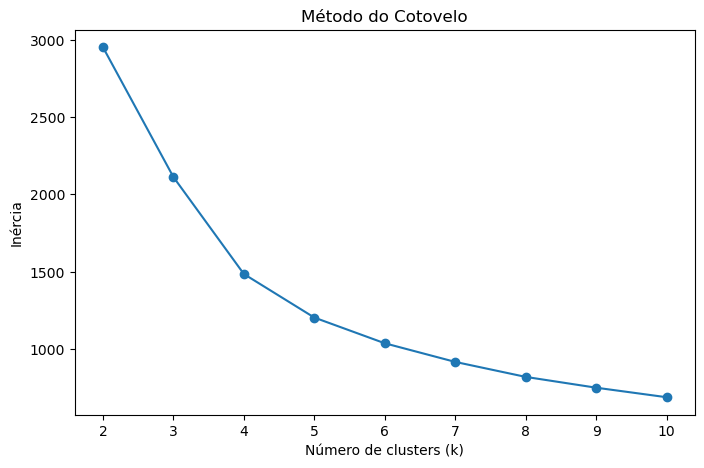

In [82]:
# Criar o gráfico do Método do Cotovelo

plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    inercias,
    marker='o'
)

plt.xlabel('Número de clusters (k)')
plt.ylabel('Inércia')
plt.title('Método do Cotovelo')

plt.show()

### Silhouette Score

Além do Método do Cotovelo, será utilizado o Silhouette Score para auxiliar na escolha do número de clusters.

Essa métrica avalia, de forma simplificada, se cada observação está próxima dos elementos do seu próprio grupo e distante dos elementos dos outros grupos.

Valores maiores indicam uma separação mais clara entre os clusters.

In [83]:
# Criar uma lista para armazenar o Silhouette Score
silhouettes = []

# Testar diferentes quantidades de clusters
for k in range(2, 11):

    # Criar o modelo K-Means
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    # Treinar o modelo e identificar o cluster de cada candidatura
    clusters = kmeans.fit_predict(X_padronizado)

    # Calcular o Silhouette Score
    score = silhouette_score(X_padronizado, clusters)

    # Guardar o resultado
    silhouettes.append(score)

# Visualizar os resultados
silhouettes

[0.4125773714995887,
 0.4471269263284132,
 0.39852291159995357,
 0.39327262590884726,
 0.3474135399257324,
 0.35221983748669217,
 0.34628483493364526,
 0.34890945288846087,
 0.32600204901211494]

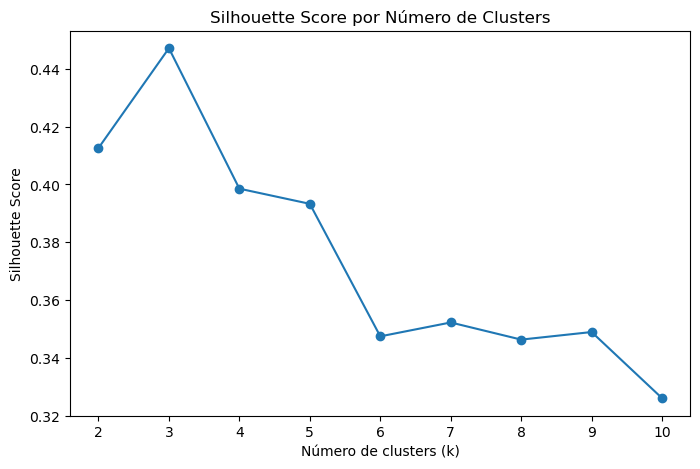

In [84]:
# Criar o gráfico do Silhouette Score

plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    silhouettes,
    marker='o'
)

plt.xlabel('Número de clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score por Número de Clusters')

plt.show()

#### Avaliação do Número de Clusters
O Método do Cotovelo indicou uma mudança mais acentuada na redução da inércia em torno de 4 clusters.

Por outro lado, o maior Silhouette Score foi obtido com 3 clusters, indicando uma separação mais clara dos grupos para esse valor de `k`.

Diante desses resultados, serão avaliadas inicialmente as soluções com 3 e 4 clusters, considerando não apenas as métricas, mas também a capacidade de cada solução gerar grupos distintos e interpretáveis.

## 6.2 Treinamento do K-Means com 3 Clusters


In [85]:
# Criar o modelo K-Means com 3 clusters
kmeans_3 = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# Treinar o modelo e identificar o cluster de cada candidatura
df_modelo['CLUSTER_3'] = kmeans_3.fit_predict(X_padronizado)

# Verificar quantas candidaturas ficaram em cada cluster
df_modelo['CLUSTER_3'].value_counts().sort_index()

0    975
1    137
2    427
Name: CLUSTER_3, dtype: int64

In [86]:
# Calcular a média das características de cada cluster

perfil_clusters_3 = (
    df_modelo
    .groupby('CLUSTER_3')[
        ['IDADE', 'PATRIMONIO_TOTAL', 'RECEITA_TOTAL']
    ]
    .mean()
    .round(2)
)

perfil_clusters_3

,IDADE,PATRIMONIO_TOTAL,RECEITA_TOTAL
CLUSTER_3,,,
0,50.48,1250776.33,465280.29
1,49.74,118893.93,4.32
2,47.16,54.65,91338.90


In [87]:
# Calcular a mediana das características de cada cluster

mediana_clusters_3 = (
    df_modelo
    .groupby('CLUSTER_3')[
        ['IDADE', 'PATRIMONIO_TOTAL', 'RECEITA_TOTAL']
    ]
    .median()
    .round(2)
)

mediana_clusters_3

,IDADE,PATRIMONIO_TOTAL,RECEITA_TOTAL
CLUSTER_3,,,
0,50.0,380000.0,106259.4
1,51.0,0.0,0.0
2,48.0,0.0,25000.0


#### Perfil Inicial da Solução com 3 Clusters

A análise das médias e medianas mostra que os três clusters apresentam diferenças principalmente nas características financeiras.

O Cluster 0 concentra candidaturas com maiores valores de patrimônio e receita. O Cluster 1 apresenta patrimônio e receita predominantemente iguais a zero, enquanto o Cluster 2 apresenta patrimônio predominantemente igual a zero, mas com presença de receita de campanha.

As diferenças de idade entre os grupos são menores quando comparadas às diferenças observadas nas variáveis financeiras.

Como as distribuições financeiras são assimétricas, as medianas serão consideradas juntamente com as médias na interpretação dos perfis.

## 6.3 Comparação com a Solução de 4 Clusters


In [88]:
# Criar o modelo K-Means com 4 clusters
kmeans_4 = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

# Treinar o modelo e identificar o cluster de cada candidatura
df_modelo['CLUSTER_4'] = kmeans_4.fit_predict(X_padronizado)

# Verificar a quantidade de candidaturas em cada cluster
df_modelo['CLUSTER_4'].value_counts().sort_index()

0    461
1    419
2    522
3    137
Name: CLUSTER_4, dtype: int64

In [89]:
# Calcular a média das características dos 4 clusters

perfil_clusters_4 = (
    df_modelo
    .groupby('CLUSTER_4')[
        ['IDADE', 'PATRIMONIO_TOTAL', 'RECEITA_TOTAL']
    ]
    .mean()
    .round(2)
)

perfil_clusters_4

,IDADE,PATRIMONIO_TOTAL,RECEITA_TOTAL
CLUSTER_4,,,
0,59.74,1416427.52,442782.64
1,47.54,6.50,86342.19
2,41.94,1085353.36,483428.76
3,49.74,118893.93,4.32


In [90]:
# Calcular a mediana das características dos 4 clusters

mediana_clusters_4 = (
    df_modelo
    .groupby('CLUSTER_4')[
        ['IDADE', 'PATRIMONIO_TOTAL', 'RECEITA_TOTAL']
    ]
    .median()
    .round(2)
)

mediana_clusters_4

,IDADE,PATRIMONIO_TOTAL,RECEITA_TOTAL
CLUSTER_4,,,
0,58.0,570458.56,98777.00
1,48.0,0.00,25000.00
2,43.0,263324.46,118500.06
3,51.0,0.00,0.00


In [91]:
# Comparar a distribuição das candidaturas
# entre as soluções com 3 e 4 clusters

pd.crosstab(
    df_modelo['CLUSTER_3'],
    df_modelo['CLUSTER_4']
)

CLUSTER_4,0,1,2,3
CLUSTER_3,,,,
0,461,1,513,0
1,0,0,0,137
2,0,418,9,0


#### Definição do Número de Clusters

Foram comparadas as soluções com 3 e 4 clusters.

A solução com 3 clusters apresentou o maior Silhouette Score (0,447), enquanto a solução com 4 clusters apresentou valor de aproximadamente 0,399.

A comparação entre as duas segmentações mostrou que a inclusão do quarto cluster subdividiu principalmente um dos grupos da solução com 3 clusters, diferenciando candidaturas com características financeiras semelhantes principalmente pela idade.

Diante desses resultados, optou-se por utilizar 3 clusters no modelo final, priorizando uma solução mais simples, com melhor Silhouette Score e grupos com diferenças interpretáveis.

# Etapa 7.0 — Interpretação dos Clusters


In [92]:
# Selecionar o identificador da candidatura e o cluster final
df_clusters = df_modelo[
    ['SQ_CANDIDATO', 'CLUSTER_3']
].copy()

# Renomear a coluna para indicar que este será o cluster final
df_clusters = df_clusters.rename(
    columns={'CLUSTER_3': 'CLUSTER'}
)

df_clusters.head()

,SQ_CANDIDATO,CLUSTER
0,250001677888,1
1,250001677870,1
2,250001738902,1
3,250001677900,2
4,250001677907,2


In [93]:
# Verificar se a coluna CLUSTER já existe na base consolidada

'CLUSTER' in df_deputados.columns

False

In [94]:
# Adicionar o cluster final à base consolidada

df_deputados = df_deputados.merge(
    df_clusters,
    on='SQ_CANDIDATO',
    how='left'
)

# Verificar a quantidade de candidaturas em cada cluster
df_deputados['CLUSTER'].value_counts(dropna=False).sort_index()

0.0    975
1.0    137
2.0    427
NaN      1
Name: CLUSTER, dtype: int64

## 7.1 Análise de Despesas e Votos por Cluster

Após a formação dos clusters, serão analisadas as despesas de campanha e a quantidade de votos das candidaturas pertencentes a cada grupo.

Essas variáveis não foram utilizadas na construção do K-Means e serão consideradas apenas para caracterizar os perfis identificados.

In [95]:
# Calcular as medianas de despesas e votos por cluster

df_deputados.groupby('CLUSTER')[
    ['DESPESA_TOTAL', 'VOTOS_TOTAL']
].median().round(2)

,DESPESA_TOTAL,VOTOS_TOTAL
CLUSTER,,
0.0,99895.35,2575.0
1.0,0.00,182.0
2.0,20000.00,485.5


In [96]:
# Verificar quantas candidaturas possuem informação de votos em cada cluster

df_deputados.groupby('CLUSTER')['VOTOS_TOTAL'].count()

CLUSTER
0.0    959
1.0     77
2.0    392
Name: VOTOS_TOTAL, dtype: int64

#### Observação sobre os Dados de Votação

A informação de votos não está disponível para todas as candidaturas presentes nos clusters.

Por esse motivo, as estatísticas de votação foram calculadas apenas para os registros que possuem informação de votos, mantendo os valores ausentes como `NaN` em vez de substituí-los por zero.

Assim, evita-se interpretar ausência de informação de votação como ausência de votos.

In [97]:
# Verificar quais resultados eleitorais existem na base
# e quantas candidaturas pertencem a cada situação

df_deputados['DS_SIT_TOT_TURNO'].value_counts(dropna=False)

SUPLENTE            783
NÃO ELEITO          605
#NULO                82
ELEITO POR QP        60
ELEITO POR MÉDIA     10
Name: DS_SIT_TOT_TURNO, dtype: int64

In [98]:
# Comparar o resultado eleitoral entre os clusters

pd.crosstab(
    df_deputados['CLUSTER'],
    df_deputados['DS_SIT_TOT_TURNO']
)

DS_SIT_TOT_TURNO,#NULO,ELEITO POR MÉDIA,ELEITO POR QP,NÃO ELEITO,SUPLENTE
CLUSTER,,,,,
0.0,10,10,59,300,596
1.0,50,0,0,70,17
2.0,22,0,1,235,169


In [99]:
# Calcular a distribuição percentual do resultado eleitoral
# dentro de cada cluster

resultado_percentual = pd.crosstab(
    df_deputados['CLUSTER'],
    df_deputados['DS_SIT_TOT_TURNO'],
    normalize='index'
) * 100

resultado_percentual.round(2)

DS_SIT_TOT_TURNO,#NULO,ELEITO POR MÉDIA,ELEITO POR QP,NÃO ELEITO,SUPLENTE
CLUSTER,,,,,
0.0,1.03,1.03,6.05,30.77,61.13
1.0,36.50,0.00,0.00,51.09,12.41
2.0,5.15,0.00,0.23,55.04,39.58


#### Resultado Eleitoral por Cluster

A distribuição percentual do resultado eleitoral apresentou diferenças entre os perfis identificados.

O Cluster 0 concentrou proporcionalmente mais candidaturas classificadas como suplentes e nas categorias de eleitos. Os Clusters 1 e 2 apresentaram maior participação de candidaturas classificadas como não eleitas, enquanto a categoria `#NULO` teve presença especialmente elevada no Cluster 1.

Esses resultados indicam uma associação entre os perfis identificados pelo K-Means e o desempenho eleitoral observado. Entretanto, a análise é descritiva e não permite concluir que características como patrimônio, receita ou despesas sejam responsáveis pelo resultado eleitoral.

In [100]:
# Criar uma tabela-resumo com o perfil típico de cada cluster
# Utilizamos a mediana porque as variáveis financeiras possuem valores extremos

perfil_clusters = (
    df_deputados
    .groupby('CLUSTER')
    .agg(
        CANDIDATURAS=('SQ_CANDIDATO', 'count'),
        IDADE_MEDIANA=('IDADE', 'median'),
        PATRIMONIO_MEDIANO=('PATRIMONIO_TOTAL', 'median'),
        RECEITA_MEDIANA=('RECEITA_TOTAL', 'median'),
        DESPESA_MEDIANA=('DESPESA_TOTAL', 'median'),
        VOTOS_MEDIANA=('VOTOS_TOTAL', 'median')
    )
    .round(2)
)

perfil_clusters

,CANDIDATURAS,IDADE_MEDIANA,PATRIMONIO_MEDIANO,RECEITA_MEDIANA,DESPESA_MEDIANA,VOTOS_MEDIANA
CLUSTER,,,,,,
0.0,975,50.0,380000.0,106259.4,99895.35,2575.0
1.0,137,51.0,0.0,0.0,0.00,182.0
2.0,427,48.0,0.0,25000.0,20000.00,485.5


In [101]:
# Criar nomes descritivos para facilitar a interpretação dos clusters

nomes_clusters = {
    0: 'Maior estrutura financeira',
    1: 'Baixa movimentação financeira',
    2: 'Estrutura financeira intermediária'
}

df_deputados['PERFIL_CLUSTER'] = (
    df_deputados['CLUSTER']
    .map(nomes_clusters)
)

df_deputados[
    ['CLUSTER', 'PERFIL_CLUSTER']
].value_counts(dropna=False)

CLUSTER  PERFIL_CLUSTER                    
0.0      Maior estrutura financeira            975
2.0      Estrutura financeira intermediária    427
1.0      Baixa movimentação financeira         137
NaN      NaN                                     1
dtype: int64

In [102]:
# Calcular a participação percentual de cada perfil
# considerando apenas as candidaturas que participaram do K-Means

(
    df_deputados['PERFIL_CLUSTER']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Maior estrutura financeira            63.35
Estrutura financeira intermediária    27.75
Baixa movimentação financeira          8.90
Name: PERFIL_CLUSTER, dtype: float64

### Conclusão da Etapa 7

A interpretação dos três clusters permitiu identificar perfis distintos entre as candidaturas analisadas.

- **Maior estrutura financeira (63,35%)**: apresenta as maiores medianas de patrimônio, receita e despesa de campanha, além da maior mediana de votos entre os três grupos.
- **Estrutura financeira intermediária (27,75%)**: apresenta patrimônio mediano igual a zero, mas possui movimentação financeira de campanha, com valores intermediários de receita, despesa e votos.
- **Baixa movimentação financeira (8,90%)**: apresenta patrimônio, receita e despesa medianos iguais a zero e a menor mediana de votos.

A idade apresentou diferenças menores entre os grupos, indicando que as características financeiras tiveram maior destaque na diferenciação dos perfis.

Também foram observadas diferenças na distribuição dos resultados eleitorais entre os clusters. Essas relações devem ser interpretadas como associações descritivas, não sendo possível estabelecer relações de causa e efeito a partir desta análise.

# Etapa 8 — Visualização dos Clusters


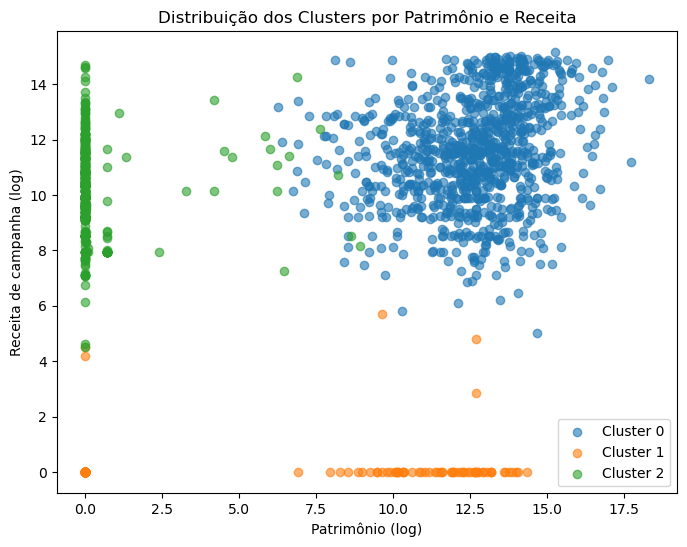

In [103]:
# Visualizar a relação entre patrimônio e receita
# de acordo com os clusters identificados


plt.figure(figsize=(8, 6))

for cluster in sorted(df_modelo['CLUSTER_3'].unique()):
    
    dados_cluster = df_modelo[df_modelo['CLUSTER_3'] == cluster]
    
    plt.scatter(
        dados_cluster['PATRIMONIO_LOG'],
        dados_cluster['RECEITA_LOG'],
        label=f'Cluster {cluster}',
        alpha=0.6
    )

plt.xlabel('Patrimônio (log)')
plt.ylabel('Receita de campanha (log)')
plt.title('Distribuição dos Clusters por Patrimônio e Receita')
plt.legend()
plt.show()

#### Interpretação

O gráfico evidencia diferenças principalmente nas características financeiras dos grupos.

O Cluster 0 concentra candidaturas com maiores níveis de patrimônio e receita de campanha. O Cluster 1 apresenta principalmente candidaturas com receita de campanha igual a zero, enquanto o Cluster 2 concentra candidaturas com patrimônio declarado igual a zero, mas que apresentam movimentação de receita de campanha.

A existência de alguma sobreposição entre os grupos é esperada, pois o modelo também considera a idade na formação dos clusters.

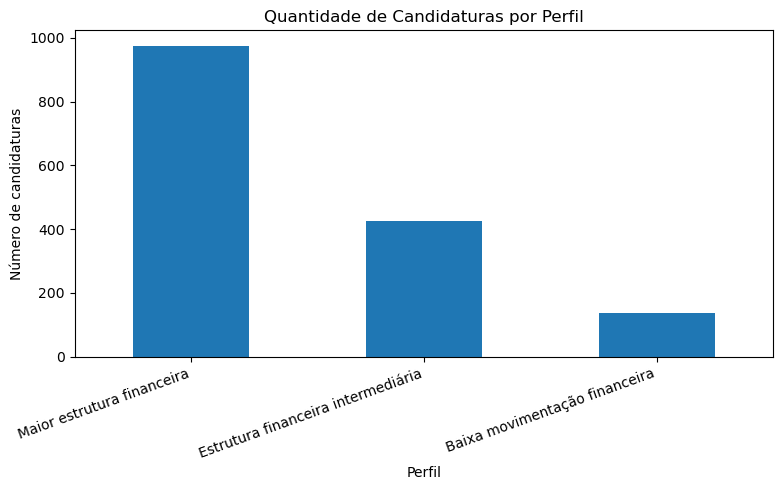

In [104]:
# Visualizar a quantidade de candidaturas em cada perfil

contagem_perfis = (
    df_deputados['PERFIL_CLUSTER']
    .value_counts()
)

plt.figure(figsize=(8, 5))

contagem_perfis.plot(kind='bar')

plt.title('Quantidade de Candidaturas por Perfil')
plt.xlabel('Perfil')
plt.ylabel('Número de candidaturas')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

#### Interpretação

A maior parte das candidaturas analisadas pertence ao perfil de Maior estrutura financeira, representando 63,35% dos registros clusterizados.

O perfil de Estrutura financeira intermediária corresponde a 27,75%, enquanto o perfil de Baixa movimentação financeira representa 8,90% das candidaturas.

Essa distribuição mostra que os grupos identificados pelo K-Means possuem tamanhos diferentes, sendo o primeiro perfil predominante na base analisada.

# Etapa 9 — Conclusão

A aplicação do K-Means permitiu identificar três perfis distintos entre as candidaturas a Deputado Federal em São Paulo nas Eleições de 2022, considerando idade, patrimônio declarado e receita de campanha.

Os grupos apresentaram diferenças principalmente em relação às características financeiras. O perfil de Maior estrutura financeira concentrou candidaturas com maiores valores típicos de patrimônio, receita e despesa, enquanto os demais grupos apresentaram menor movimentação financeira ou patrimônio declarado igual a zero como característica predominante.

A análise posterior também mostrou diferenças na distribuição de votos e resultados eleitorais entre os grupos. Essas diferenças representam associações observadas nos dados e não permitem estabelecer relações de causa e efeito.

O projeto demonstra como técnicas de aprendizado não supervisionado podem ser utilizadas para explorar bases eleitorais e identificar padrões que não estavam previamente definidos.

In [105]:
# Selecionar as informações que serão utilizadas na base final
# para análise e construção do dashboard no Power BI

colunas_finais = [
    'SQ_CANDIDATO',
    'NR_CANDIDATO',
    'NM_CANDIDATO',
    'NM_URNA_CANDIDATO',
    'SG_PARTIDO',
    'DS_GENERO',
    'DS_GRAU_INSTRUCAO',
    'DS_OCUPACAO',
    'DS_SITUACAO_CANDIDATURA',
    'DS_SIT_TOT_TURNO',
    'IDADE',
    'PATRIMONIO_TOTAL',
    'RECEITA_TOTAL',
    'DESPESA_TOTAL',
    'VOTOS_TOTAL',
    'CLUSTER',
    'PERFIL_CLUSTER'
]

df_final = df_deputados[colunas_finais].copy()

df_final.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1540 entries, 0 to 1539
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   SQ_CANDIDATO             1540 non-null   int64  
 1   NR_CANDIDATO             1540 non-null   int64  
 2   NM_CANDIDATO             1540 non-null   object 
 3   NM_URNA_CANDIDATO        1540 non-null   object 
 4   SG_PARTIDO               1540 non-null   object 
 5   DS_GENERO                1540 non-null   object 
 6   DS_GRAU_INSTRUCAO        1540 non-null   object 
 7   DS_OCUPACAO              1540 non-null   object 
 8   DS_SITUACAO_CANDIDATURA  1540 non-null   object 
 9   DS_SIT_TOT_TURNO         1540 non-null   object 
 10  IDADE                    1539 non-null   float64
 11  PATRIMONIO_TOTAL         1540 non-null   float64
 12  RECEITA_TOTAL            1540 non-null   float64
 13  DESPESA_TOTAL            1540 non-null   float64
 14  VOTOS_TOTAL             

In [106]:
# Verificar se cada candidatura aparece apenas uma vez na base final

df_final['SQ_CANDIDATO'].duplicated().sum()

0

In [108]:
# Exportar a base final para utilização no Power BI

df_final.to_csv(
    'C:/Users/Felipe/Desktop/Clusterização/Dados/base_final_clusters.csv',
    index=False,
    encoding='utf-8-sig'
)